# Single Layer Perceptron (SLP) — Klasifikasi Biner Iris



## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator


## 2. Load Dataset

Dataset dibaca dari file CSV (`iris_setosa_versicolor.csv`) berisi 100 baris
(50 Iris-setosa + 50 Iris-versicolor), kolom `x1..x4` = fitur, `target` = label
(0 = setosa, 1 = versicolor).


In [6]:
def load_dataset(path="iris_setosa_versicolor.csv"):

    df = pd.read_csv(path)
    feature_cols = [c for c in df.columns if c != "target"]
    X = df[feature_cols].values
    y = df["target"].values
    return X, y


X, y = load_dataset()
print(f"Total data: {len(X)} samples, {X.shape[1]} features")
print(f"Kelas 0 (setosa): {(y == 0).sum()}, Kelas 1 (versicolor): {(y == 1).sum()}")


Total data: 100 samples, 4 features
Kelas 0 (setosa): 50, Kelas 1 (versicolor): 50


## 3. Split Train / Validation

Splitting dilakukan lewat fungsi `split_dataset()` — **bukan** dipisah manual
jadi dua variabel/file terpisah. Aturan split-nya: per kelas, ambil `n_train_per_class`
data pertama untuk training, sisanya untuk validation (*stratified sequential split*).


In [7]:
def split_dataset(X, y, n_train_per_class):

    X_train, X_val, y_train, y_val = [], [], [], []

    for cls in np.unique(y):
        cls_idx = np.where(y == cls)[0]  # keep original order (no shuffle)
        train_idx = cls_idx[:n_train_per_class]
        val_idx = cls_idx[n_train_per_class:]

        X_train.append(X[train_idx]); y_train.append(y[train_idx])
        X_val.append(X[val_idx]);     y_val.append(y[val_idx])

    X_train = np.concatenate(X_train); y_train = np.concatenate(y_train)
    X_val = np.concatenate(X_val);     y_val = np.concatenate(y_val)
    return X_train, X_val, y_train, y_val


X_train, X_val, y_train, y_val = split_dataset(X, y, n_train_per_class=40)
print(f"Training: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")


Training: 80 samples
Validation: 20 samples


## 4. Fungsi-fungsi Model


In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def forward(x, w, b):
    z = np.dot(w, x) + b
    g = sigmoid(z)
    pred = 1 if g > 0.5 else 0
    return z, g, pred


In [9]:
def train_slp(X, y, w, b, learning_rate, n_epochs):
    train_loss, train_acc, epoch_weights = [], [], []

    for epoch in range(n_epochs):
        squared_errors = []
        correct = 0

        for i in range(len(X)):
            xi, yi = X[i], y[i]
            z, g, pred = forward(xi, w, b)

            error = g - yi
            squared_errors.append(error ** 2)
            correct += int(pred == yi)

            # gradient descent
            db = 2 * error * (1 - g) * g
            dw = db * xi
            b = b - learning_rate * db
            w = w - learning_rate * dw

        train_loss.append(np.mean(squared_errors))
        train_acc.append(correct / len(X))
        epoch_weights.append((w.copy(), b))

    return train_loss, train_acc, epoch_weights


In [10]:
def validate_slp(X, y, epoch_weights):
    val_loss, val_acc = [], []

    for w, b in epoch_weights:
        squared_errors = []
        correct = 0
        for i in range(len(X)):
            xi, yi = X[i], y[i]
            z, g, pred = forward(xi, w, b)
            error = g - yi
            squared_errors.append(error ** 2)
            correct += int(pred == yi)

        val_loss.append(np.mean(squared_errors))
        val_acc.append(correct / len(X))

    return val_loss, val_acc


## 5. Jalankan Training + Validation

In [11]:
# Hyperparameters
LEARNING_RATE = 0.1
N_EPOCHS = 5
n_features = X_train.shape[1]

# Initial weights
w0 = np.full(n_features, 0.5)
b0 = 0.5

train_loss, train_acc, epoch_weights = train_slp(
    X_train, y_train, w0, b0, LEARNING_RATE, N_EPOCHS
)
val_loss, val_acc = validate_slp(X_val, y_val, epoch_weights)

results = pd.DataFrame({
    "epoch": range(1, N_EPOCHS + 1),
    "train_loss": train_loss,
    "train_acc": train_acc,
    "val_loss": val_loss,
    "val_acc": val_acc,
})
results


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,0.449889,0.5250,0.328951,0.50
1,2,0.037452,0.9500,0.247289,0.50
2,3,0.024372,0.9750,0.175892,0.50
3,4,0.017357,0.9750,0.119381,0.85
4,5,0.012740,0.9875,0.081581,1.00


## 6. Visualisasi Hasil



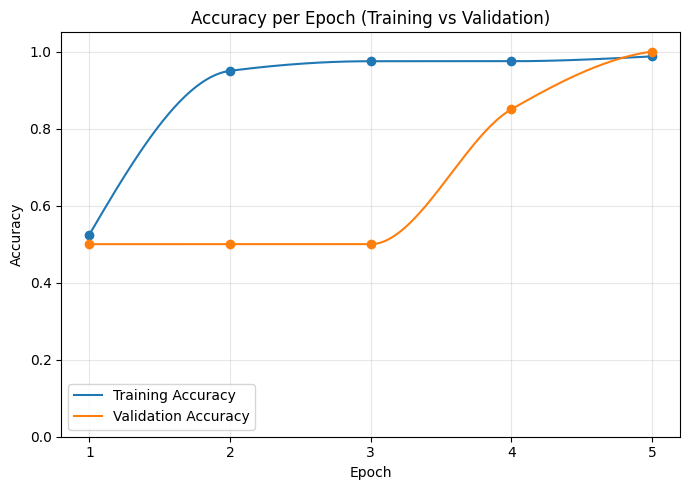

In [12]:
def smooth_curve(x, y, n_points=200):
    """
    Return a smooth interpolated curve through (x, y) for nicer-looking
    plots. Uses PCHIP so the curve never overshoots above/below the actual
    data points (safe for bounded values like accuracy 0..1).
    """
    x = np.array(x)
    y = np.array(y)
    x_smooth = np.linspace(x.min(), x.max(), n_points)
    y_smooth = PchipInterpolator(x, y)(x_smooth)
    return x_smooth, y_smooth


def plot_accuracy(results):
    plt.figure(figsize=(7, 5))
    for col, label in [("train_acc", "Training Accuracy"), ("val_acc", "Validation Accuracy")]:
        xs, ys = smooth_curve(results["epoch"], results[col])
        line, = plt.plot(xs, ys, label=label)
        plt.plot(results["epoch"], results[col], "o", color=line.get_color())
    plt.title("Accuracy per Epoch (Training vs Validation)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.xticks(results["epoch"])
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("accuracy_chart.png", dpi=150)
    plt.show()


plot_accuracy(results)


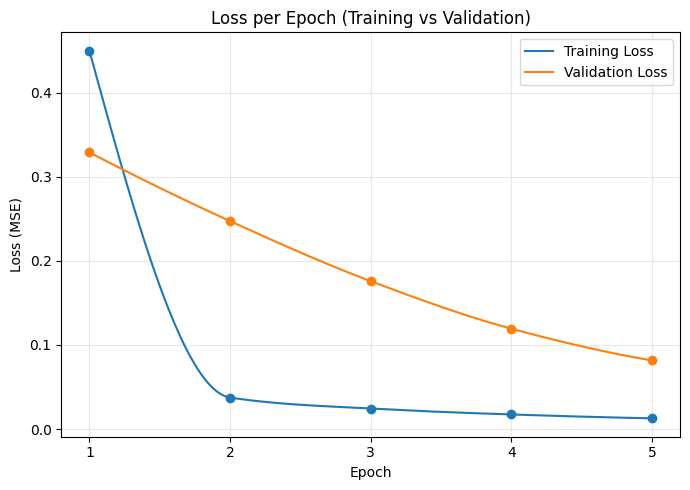

In [13]:
def plot_loss(results):
    plt.figure(figsize=(7, 5))
    for col, label in [("train_loss", "Training Loss"), ("val_loss", "Validation Loss")]:
        xs, ys = smooth_curve(results["epoch"], results[col])
        line, = plt.plot(xs, ys, label=label)
        plt.plot(results["epoch"], results[col], "o", color=line.get_color())
    plt.title("Loss per Epoch (Training vs Validation)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MSE)")
    plt.xticks(results["epoch"])
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("loss_chart.png", dpi=150)
    plt.show()


plot_loss(results)
